In [18]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress=True)
import copy

In [19]:
area = np.array([4.1, 27.6, 11.3, 38.9, 19.4, 8.7, 33.2, 15.8, 41.5, 22.9, 6.3, 29.8, 13.4, 36.1, 17.2, 44.7, 9.9, 25.3, 31.6, 12.1, 40.2, 18.6, 7.5, 34.8, 21.7, 10.4, 37.3, 16.5, 42.9, 23.8, 5.2, 28.4, 14.7, 39.6, 20.3, 45.8, 11.9, 26.7, 32.5, 8.1, 43.4, 24.6, 35.7, 30.1, 13.8])
wind_speed = np.array([31.2, 7.4, 45.8, 18.6, 3.9, 52.1, 26.3, 39.7, 11.2, 48.5, 22.8, 5.1, 35.4, 43.2, 14.7, 29.6, 8.3, 50.9, 17.1, 37.8, 24.5, 2.6, 41.3, 12.9, 46.7, 33.1, 20.4, 6.8, 28.2, 15.3, 44.6, 38.4, 25.7, 9.6, 53.2, 21.1, 30.5, 4.3, 47.9, 16.8, 36.2, 13.5, 42.8, 19.9, 27.4])
x_train = np.array([area, wind_speed, area*wind_speed, area*(wind_speed**2)])
y_train = np.array([21.4, 55.9, 122.6, 194.3, 27.3, 130.8, 267.1, 168.2, 122.9, 348.7, 33.2, 55.2, 148.9, 447.6, 82.0, 486.5, 24.9, 425.4, 200.7, 129.6, 383.5, 22.4, 90.6, 187.4, 372.5, 122.8, 292.9, 45.5, 507.6, 156.6, 51.1, 448.8, 156.2, 129.9, 424.4, 429.3, 138.6, 39.6, 553.9, 44.2, 502.5, 129.3, 505.6, 245.1, 149.8])
x_train = x_train.T

In [20]:
scaler = StandardScaler()

x_new_train = scaler.fit_transform(x_train)

print(scaler.mean_,"\n" ,scaler.scale_)
print(x_new_train)

[   24.1     26.96   616.74 20794.98] 
 [   12.27    14.99   458.66 21466.52]
[[-1.63  0.28 -1.07 -0.78]
 [ 0.29 -1.31 -0.9  -0.9 ]
 [-1.04  1.26 -0.22  0.14]
 [ 1.21 -0.56  0.23 -0.34]
 [-0.38 -1.54 -1.18 -0.95]
 [-1.25  1.68 -0.36  0.13]
 [ 0.74 -0.04  0.56  0.1 ]
 [-0.68  0.85  0.02  0.19]
 [ 1.42 -1.05 -0.33 -0.73]
 [-0.1   1.44  1.08  1.54]
 [-1.45 -0.28 -1.03 -0.82]
 [ 0.46 -1.46 -1.01 -0.93]
 [-0.87  0.56 -0.31 -0.19]
 [ 0.98  1.08  2.06  2.17]
 [-0.56 -0.82 -0.79 -0.8 ]
 [ 1.68  0.18  1.54  0.86]
 [-1.16 -1.25 -1.17 -0.94]
 [ 0.1   1.6   1.46  2.08]
 [ 0.61 -0.66 -0.17 -0.54]
 [-0.98  0.72 -0.35 -0.16]
 [ 1.31 -0.16  0.8   0.16]
 [-0.45 -1.63 -1.24 -0.96]
 [-1.35  0.96 -0.67 -0.37]
 [ 0.87 -0.94 -0.37 -0.7 ]
 [-0.2   1.32  0.86  1.24]
 [-1.12  0.41 -0.59 -0.44]
 [ 1.08 -0.44  0.31 -0.25]
 [-0.62 -1.35 -1.1  -0.93]
 [ 1.53  0.08  1.29  0.62]
 [-0.02 -0.78 -0.55 -0.71]
 [-1.54  1.18 -0.84 -0.49]
 [ 0.35  0.76  1.03  0.98]
 [-0.77 -0.08 -0.52 -0.52]
 [ 1.26 -1.16 -0.52 -0.8 ]
 [-0

In [23]:
sgdr = SGDRegressor(max_iter = 10000, tol=1e-6)
sgdr.fit(x_new_train, y_train)


SGDRegressor(max_iter=10000, tol=1e-06)

In [24]:
print(f"No of iterations it took {sgdr.n_iter_}, total weight update {sgdr.t_}")
print(f"final w {sgdr.coef_}, final b {sgdr.intercept_}")

No of iterations it took 3827, total weight update 172216.0
final w [  3.58  -3.87 178.05 -18.89], final b [213.88]


In [25]:
print(f"Accuracy of the model {sgdr.score(x_new_train, y_train)*100:.2f}")

Accuracy of the model 95.58


In [26]:
prediction = sgdr.predict(x_new_train)

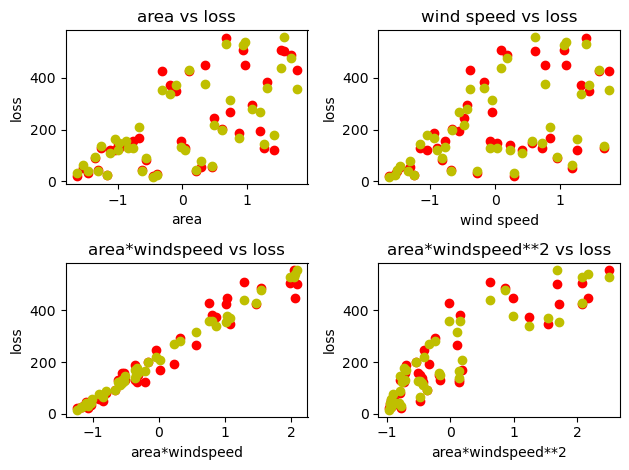

In [27]:
fig, ax = plt.subplots(2, 2)
x_scaled = copy.deepcopy(x_new_train)

ax[0, 0].scatter(x_scaled[:, 0], y_train, color = "r", marker="o")
ax[0, 0].scatter(x_scaled[:, 0], prediction, color = "y", marker = "o")
ax[0,0].set_title("area vs loss")
ax[0, 0].set_xlabel("area")
ax[0, 0].set_ylabel("loss")

ax[0, 1].scatter(x_scaled[:, 1], y_train, color = "r", marker="o")
ax[0, 1].scatter(x_scaled[:, 1], prediction, color = "y", marker = "o")
ax[0, 1].set_title("wind speed vs loss")
ax[0, 1].set_xlabel("wind speed")
ax[0, 1].set_ylabel("loss")

ax[1, 0].scatter(x_scaled[:, 2], y_train, color = "r", marker="o")
ax[1, 0].scatter(x_scaled[:, 2], prediction, color = "y", marker = "o")
ax[1,0].set_title("area*windspeed vs loss")
ax[1, 0].set_xlabel("area*windspeed")
ax[1, 0].set_ylabel("loss")

ax[1, 1].scatter(x_scaled[:, 3], y_train, color = "r", marker="o")
ax[1, 1].scatter(x_scaled[:, 3], prediction, color = "y", marker = "o")
ax[1, 1].set_title("area*windspeed**2 vs loss")
ax[1, 1].set_xlabel("area*windspeed**2")
ax[1, 1].set_ylabel("loss")

plt.tight_layout();
plt.show()

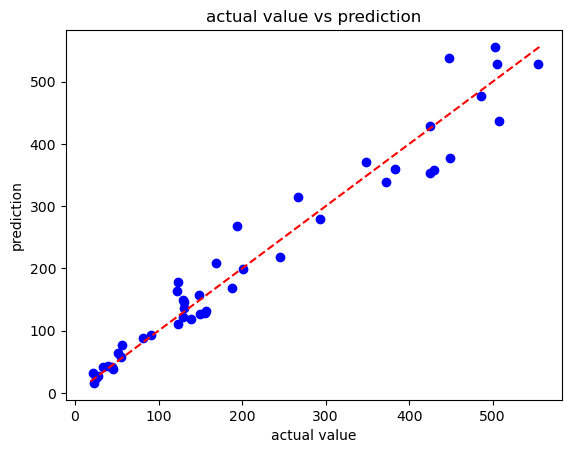

In [28]:
plt.scatter(y_train, prediction, color="b", marker="o")

hi = max(max(y_train), max(prediction))
lo = min(min(y_train), min(prediction))

plt.plot([hi, lo], [hi, lo], color = "r", linestyle='--')
plt.title("actual value vs prediction")
plt.xlabel("actual value")
plt.ylabel("prediction")

plt.show()

In [29]:
area1 = np.array([18])
wind1 = np.array([22])
user_input = np.array([area1, wind1, area1*wind1, area1*(wind1**2)])
user_input = user_input.T
user_scaled = scaler.transform(user_input)

final_prediction = sgdr.predict(user_scaled)
print(f"Loss for 18 hectare and winds of 22km/hr is {final_prediction}")

Loss for 18 hectare and winds of 22km/hr is [138.33]
